# Experiment 5: Naive Bayes Classification (PlayTennis)

Objective: build a **Naive Bayes** classifier to predict whether to **Play Tennis** based on weather conditions.

Key idea: the dataset contains **categorical** features (strings). Many ML models (including GaussianNB) require numeric input, so we use **One-Hot Encoding** to convert categories into numeric columns.

Workflow: load → inspect → select `X`/`y` → train/test split → encode categorical features → train Naive Bayes → evaluate → confusion matrix → (extra) inspect probabilities and compare with a Decision Tree → create a prediction function.


In [1]:
import pandas

#### Load dataset
We load the PlayTennis dataset. It contains weather attributes like outlook, temperature, humidity, and wind, plus a target label (play or not).


In [2]:
df = pandas.read_csv('PlayTennis.xls')

In [3]:
df.shape

(14, 5)

In [4]:
df.head()

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes


#### Missing values
We check for missing values. If there are missing values, we should handle them before encoding/training.


In [5]:
df.isnull().sum()

outlook     0
temp        0
humidity    0
windy       0
play        0
dtype: int64

#### Dataset summary
`describe()` is mainly useful for numeric columns. Since most features are categorical here, it may not show much, but it is still fine to keep.


In [6]:
df.describe()

,outlook,temp,humidity,windy,play
count,14,14,14,14,14
unique,3,3,2,2,2
top,sunny,mild,high,False,yes
freq,5,6,7,8,9


#### Create independent (X) and dependent (y) variables
- **X (features)**: the first four columns (weather conditions)
- **y (target)**: the last column (PlayTennis decision)


In [7]:
X = df.iloc[:, 0: 4]

In [8]:
X

,outlook,temp,humidity,windy
0,sunny,hot,high,False
1,sunny,hot,high,True
2,overcast,hot,high,False
3,rainy,mild,high,False
4,rainy,cool,normal,False
5,rainy,cool,normal,True
6,overcast,cool,normal,True
7,sunny,mild,high,False
8,sunny,cool,normal,False
9,rainy,mild,normal,False


In [9]:
y = df.iloc[:, -1]

In [10]:
y

0      no
1      no
2     yes
3     yes
4     yes
5      no
6     yes
7      no
8     yes
9     yes
10    yes
11    yes
12    yes
13     no
Name: play, dtype: object

In [11]:
import sklearn.model_selection

#### Train/test split (before encoding)
This split is fine for exploration, but note: once we encode data, we should split the **encoded** features (which you do later).


In [12]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.naive_bayes import GaussianNB

In [14]:
model = GaussianNB()

**model.fit will throw an error as it only accepts float, and we are passing string 'overcast'**

**in such a case we use one hot encoding. why? because it is efficient that calculating the binary and its power required for calculating binary and takes less space than the label encoder which converts strings by sorting them alphabetically and giving an integer to each row.**

In [15]:
from sklearn.preprocessing import OneHotEncoder

In [16]:
import numpy

In [17]:
one_hot_encoded = OneHotEncoder(sparse_output=False, dtype=numpy.int32)

**home task: write a function which will accept the values from the user for outlook, temp, humidity, wind and return the answer as PlayTenis or do not play**
**Find the suitable dataset for naive base algorithm and repeat all the steps for identified**

#### One-Hot Encoding
One-hot encoding converts each category into a separate 0/1 column.

Example idea:
- `outlook = sunny/overcast/rain` becomes three columns: `outlook_sunny`, `outlook_overcast`, `outlook_rain`.

This prevents the model from assuming a fake numeric order between categories (which can happen with label encoding).


In [18]:
X_new = one_hot_encoded.fit_transform(X)

In [19]:
X_new.shape

(14, 10)

#### Split encoded data
Now we split the numeric one-hot encoded features with the same target labels.


In [20]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X_new, y, test_size=0.2, random_state=42)

In [21]:
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

          no       0.50      1.00      0.67         1
         yes       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



#### Evaluation
- **Accuracy**: overall percentage of correct predictions
- **Classification report**: precision/recall/F1 for each class (helps when classes are imbalanced)

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [25]:
cm = confusion_matrix(y_test, y_pred)

#### Confusion matrix
The confusion matrix shows how many examples were classified correctly vs. incorrectly for each class.

In [26]:
# Show class probabilities
print("Class priors:", model.class_prior_)
print("Feature probabilities:", model.theta_)

Class priors: [0.36363636 0.63636364]
Feature probabilities: [[0.         0.5        0.5        0.25       0.25       0.5
  0.75       0.25       0.25       0.75      ]
 [0.42857143 0.28571429 0.28571429 0.42857143 0.28571429 0.28571429
  0.28571429 0.71428571 0.71428571 0.28571429]]


#### Naive Bayes internals (optional)
- `class_prior_`: prior probability of each class (based on training data)
- `theta_`: per-class mean of each feature (GaussianNB assumes each feature follows a Gaussian distribution)

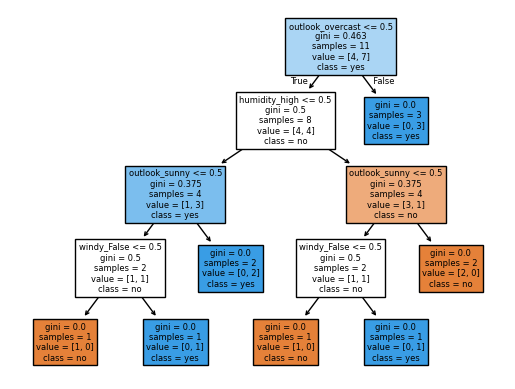

In [27]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)
plot_tree(tree_model, feature_names=one_hot_encoded.get_feature_names_out(), class_names=model.classes_, filled=True)
plt.show()

#### Comparison model (Decision Tree)
This is an extra comparison: a decision tree can also handle one-hot encoded features and may fit the small dataset easily.

In [28]:
def predict_play_tennis(outlook, temp, humidity, windy):
    import pandas as pd

    # Numeric -> categorical mappings
    outlook_map = {0: 'sunny', 1: 'overcast', 2: 'rain'}
    temp_map = {0: 'cold', 1: 'normal', 2: 'hot'}
    humidity_map = {0: 'low', 1: 'high'}
    windy_map = {0: False, 1: True}

    if outlook not in outlook_map:
        raise ValueError(f"Invalid outlook={outlook}. Expected one of {list(outlook_map.keys())}")
    if temp not in temp_map:
        raise ValueError(f"Invalid temp={temp}. Expected one of {list(temp_map.keys())}")
    if humidity not in humidity_map:
        raise ValueError(f"Invalid humidity={humidity}. Expected one of {list(humidity_map.keys())}")
    if windy not in windy_map:
        raise ValueError(f"Invalid windy={windy}. Expected 0 or 1")

    input_data = pd.DataFrame({
        'outlook': [outlook_map[outlook]],
        'temp': [temp_map[temp]],
        'humidity': [humidity_map[humidity]],
        'windy': [windy_map[windy]]
    })

    input_encoded = one_hot_encoded.transform(input_data)
    prediction = model.predict(input_encoded)
    return prediction[0]


#### User input prediction function
This function accepts user-provided values, encodes them with the same encoder, and returns the model prediction.


In [29]:
result = predict_play_tennis(0, 2, 1, 1)
print(f"Prediction: {result}")

Prediction: no
